In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer, make_column_transformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# Activity 2.3.3 - Abstracting away the learning model and non-linear transformations with `sklearn`'s `Pipeline` and `ColumnTransformer`

In the third part of this activity, we will illustrate methods for combining multiple grid searches into a single grid search.  This is useful because it allows us to abstract away the learning model and non-linear transformations, which can make our code more concise and easier to read.

## Example Data - `airquality.csv` 

We will be using a previous dataset `airquality.csv`, which involved some missing data as well as non-linearity, but this time we will explore modeling the non-linearity with either polynomial features or splines.

In [4]:
(airqual :=
 pl.read_csv("data/airquality (1).csv")
   .drop('rownames')
)

Ozone,Solar.R,Wind,Temp,Month,Day
i64,i64,f64,i64,i64,i64
41,190,7.4,67,5,1
36,118,8.0,72,5,2
12,149,12.6,74,5,3
18,313,11.5,62,5,4
null,null,14.3,56,5,5
…,…,…,…,…,…
30,193,6.9,70,9,26
null,145,13.2,77,9,27
14,191,14.3,75,9,28


In [5]:
(aq_has_target :=
 airqual
 .filter(pl.col('Ozone').is_not_null())
)

Ozone,Solar.R,Wind,Temp,Month,Day
i64,i64,f64,i64,i64,i64
41,190,7.4,67,5,1
36,118,8.0,72,5,2
12,149,12.6,74,5,3
18,313,11.5,62,5,4
28,null,14.9,66,5,6
…,…,…,…,…,…
14,20,16.6,63,9,25
30,193,6.9,70,9,26
14,191,14.3,75,9,28


In [6]:
(aq_has_target_stacked :=
 aq_has_target
 .unpivot(on = cs.numeric() - cs.by_name('Ozone'),
          index = 'Ozone',
          variable_name = 'Feature',
          value_name = 'Value',
         )

)

Ozone,Feature,Value
i64,str,f64
41,"""Solar.R""",190.0
36,"""Solar.R""",118.0
12,"""Solar.R""",149.0
18,"""Solar.R""",313.0
28,"""Solar.R""",null
…,…,…
14,"""Day""",25.0
30,"""Day""",26.0
14,"""Day""",28.0


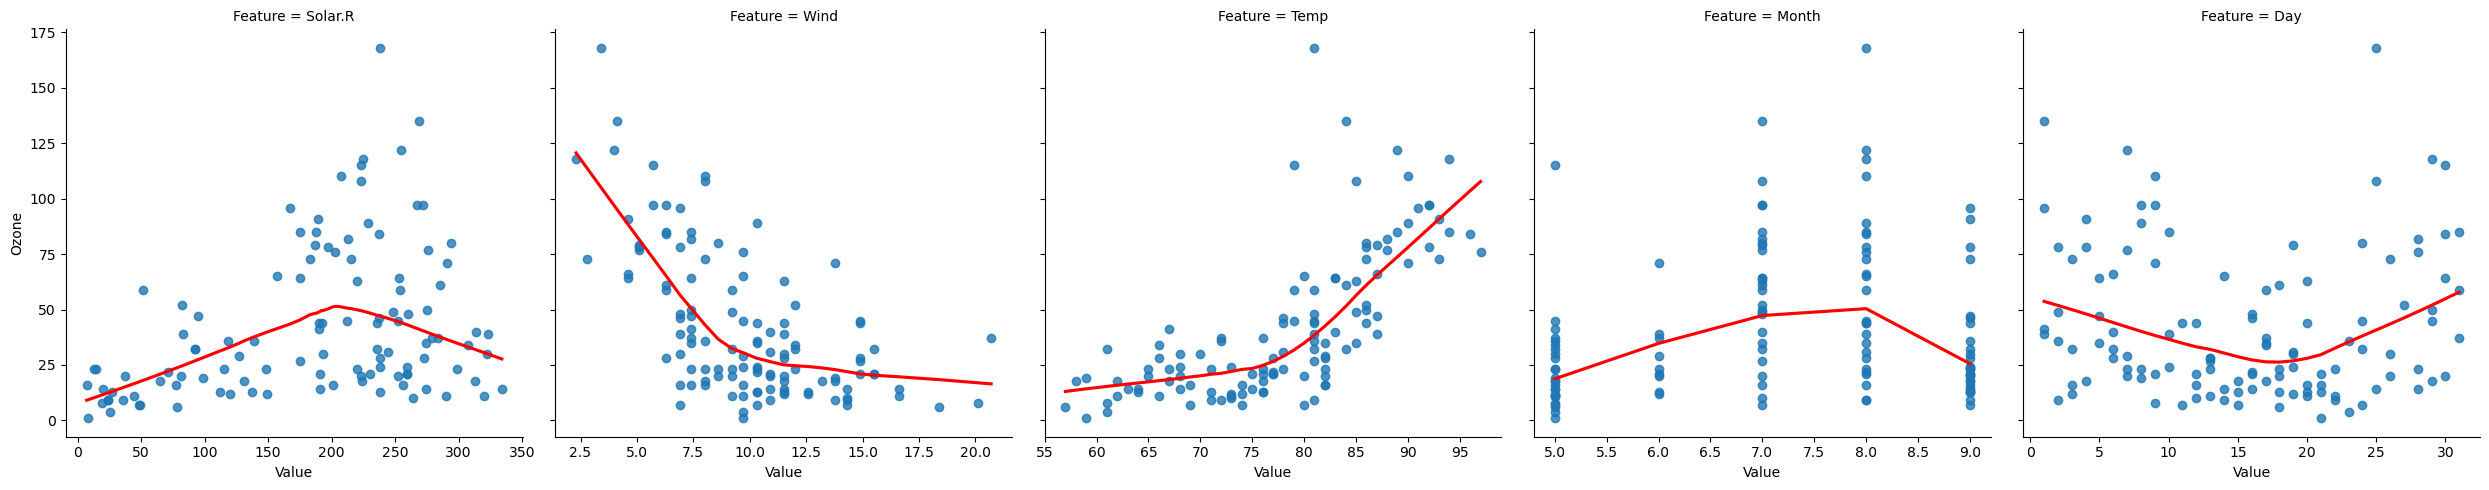

In [7]:
sns.lmplot(aq_has_target_stacked.to_pandas(),
           x = 'Value',
           y = 'Ozone',
           col = 'Feature',
           lowess = True,
           facet_kws = {'sharex':False,},
           line_kws={'color': 'red'},
           )

In [8]:
(X_train :=
 aq_has_target
 .drop('Ozone')
 .to_pandas()
 )

,Solar.R,Wind,Temp,Month,Day
0,190.0,7.4,67,5,1
1,118.0,8.0,72,5,2
2,149.0,12.6,74,5,3
3,313.0,11.5,62,5,4
4,NaN,14.9,66,5,6
...,...,...,...,...,...
111,20.0,16.6,63,9,25
112,193.0,6.9,70,9,26
113,191.0,14.3,75,9,28
114,131.0,8.0,76,9,29


In [9]:
(y_train :=
 aq_has_target
 .get_column('Ozone')
 .to_numpy()
)

array([ 41,  36,  12,  18,  28,  23,  19,   8,   7,  16,  11,  14,  18,
        14,  34,   6,  30,  11,   1,  11,   4,  32,  23,  45, 115,  37,
        29,  71,  39,  23,  21,  37,  20,  12,  13, 135,  49,  32,  64,
        40,  77,  97,  97,  85,  10,  27,   7,  48,  35,  61,  79,  63,
        16,  80, 108,  20,  52,  82,  50,  64,  59,  39,   9,  16,  78,
        35,  66, 122,  89, 110,  44,  28,  65,  22,  59,  23,  31,  44,
        21,   9,  45, 168,  73,  76, 118,  84,  85,  96,  78,  73,  91,
        47,  32,  20,  23,  21,  24,  44,  21,  28,   9,  13,  46,  18,
        13,  24,  16,  13,  23,  36,   7,  14,  30,  14,  18,  20])

In [10]:
(poly_complete :=
 make_pipeline(StandardScaler(), PolynomialFeatures())
)

,steps,"[('standardscaler', ...), ('polynomialfeatures', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [11]:
(poly_w_missing :=
 make_pipeline(SimpleImputer(),
               StandardScaler(),
               PolynomialFeatures()))

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [12]:
(preprocessing :=
 make_column_transformer(
     (poly_complete, ['Wind']),
     (poly_complete, ['Temp']),
     (poly_complete, ['Month']),
     (poly_complete, ['Day']),
     (poly_w_missing, ['Solar.R']),
 )
)

,transformers,"[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Understanding `sklearn`'s `Pipeline` and `ColumnTransformer` naming conventions
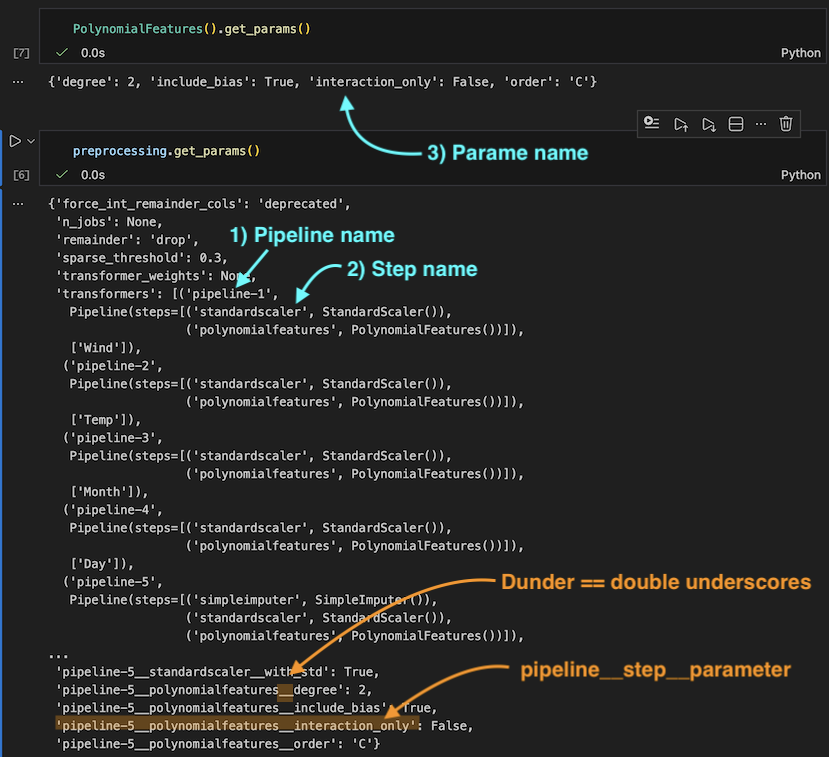

### Understanding `sklearn`'s `Pipeline` and `ColumnTransformer` naming conventions (cont.)

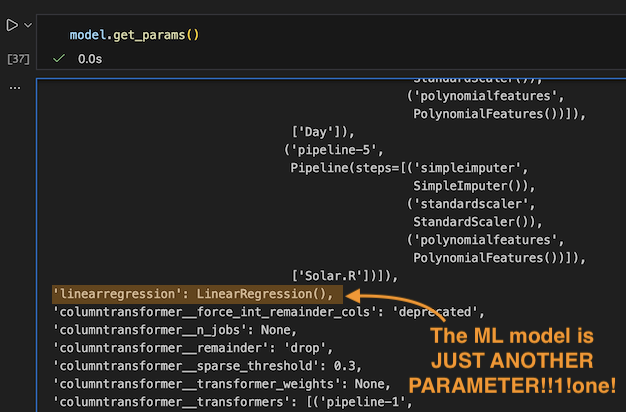

In [13]:
(model := 
  make_pipeline(preprocessing, LinearRegression()   )

)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Understanding `sklearn`'s `Pipeline` and `ColumnTransformer` naming conventions (cont.)

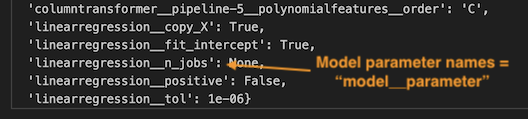

## Example 1 - Using a `TranformedTargetRegressor` to abstract away the learning model

First, we can use a `TransformedTargetRegressor` to abstract away the learning model.  This allows us to specify the learning model as part of the grid search parameters, rather than having to make a separate grid search for each learning method.

In [14]:
Y = np.array([1,2,3,4,5,6,7,8,9,10])
X = np.array([0,1,3,5,3,5,7,9,8,9]).reshape((-1, 1))

In [15]:
(model := TransformedTargetRegressor()
)

,regressor,None
,transformer,None
,func,None
,inverse_func,None
,check_inverse,True


In [16]:
(params := [
    {
        "regressor": [LinearRegression()],
        "regressor__fit_intercept": [True, False]
    },
    {
        "regressor": [KNeighborsRegressor()],
        "regressor__n_neighbors": [2,3,4,5]
    }
]
)

[{'regressor': [LinearRegression()],
  'regressor__fit_intercept': [True, False]},
 {'regressor': [KNeighborsRegressor()],
  'regressor__n_neighbors': [2, 3, 4, 5]}]

In [17]:
g = GridSearchCV(model, params)
g.fit(X, Y)

g.best_estimator_, g.best_score_, g.best_params_

(TransformedTargetRegressor(regressor=LinearRegression(fit_intercept=False)),
 np.float64(-5.175450875385684),
 {'regressor': LinearRegression(), 'regressor__fit_intercept': False})

In [18]:
(example_transformed_regressor :=
 TransformedTargetRegressor()

)

,regressor,None
,transformer,None
,func,None
,inverse_func,None
,check_inverse,True


## Example 2 - Abstracting away the regressor selections with a preprocessor

**Before.**
1. Make a separate grid search for each learning method (e.g., OLS and kNN),
2. perform the grid search for each learning method, and
3. compare the CV MSE to determine which model performed the best.

**After.**
1. Make a single grid search that includes incorporates both learning methods (e.g., OLS and kNN) as part of the grid search parameters, and
2. Perform the grid search and compare the CV MSE to determine which model performed the best.

In [19]:
(generic_model :=
  make_pipeline(preprocessing, TransformedTargetRegressor())
)

,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
[p for p in generic_model.get_params() if 'degree' in p or 'regressor' in p]

['transformedtargetregressor',
 'columntransformer__pipeline-1__polynomialfeatures__degree',
 'columntransformer__pipeline-2__polynomialfeatures__degree',
 'columntransformer__pipeline-3__polynomialfeatures__degree',
 'columntransformer__pipeline-4__polynomialfeatures__degree',
 'columntransformer__pipeline-5__polynomialfeatures__degree',
 'transformedtargetregressor__check_inverse',
 'transformedtargetregressor__func',
 'transformedtargetregressor__inverse_func',
 'transformedtargetregressor__regressor',
 'transformedtargetregressor__transformer']

In [21]:
(shared_params :=
 {'columntransformer__pipeline-1__polynomialfeatures__degree':[1,2,3],
  'columntransformer__pipeline-2__polynomialfeatures__degree': [1,2,3],
  'columntransformer__pipeline-3__polynomialfeatures__degree': [1,2,3],
  'columntransformer__pipeline-4__polynomialfeatures__degree': [1,2,3],
  'columntransformer__pipeline-5__polynomialfeatures__degree': [1,2,3],
})

{'columntransformer__pipeline-1__polynomialfeatures__degree': [1, 2, 3],
 'columntransformer__pipeline-2__polynomialfeatures__degree': [1, 2, 3],
 'columntransformer__pipeline-3__polynomialfeatures__degree': [1, 2, 3],
 'columntransformer__pipeline-4__polynomialfeatures__degree': [1, 2, 3],
 'columntransformer__pipeline-5__polynomialfeatures__degree': [1, 2, 3]}

In [22]:
KNeighborsRegressor().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [23]:
(parameters := 
 [
     shared_params | {'transformedtargetregressor__regressor':[LinearRegression()]},
     shared_params | {'transformedtargetregressor__regressor':[KNeighborsRegressor()], 'transformedtargetregressor__regressor__n_neighbors':[2,3,4,5]}
 ]
)

[{'columntransformer__pipeline-1__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-2__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-3__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-4__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-5__polynomialfeatures__degree': [1, 2, 3],
  'transformedtargetregressor__regressor': [LinearRegression()]},
 {'columntransformer__pipeline-1__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-2__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-3__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-4__polynomialfeatures__degree': [1, 2, 3],
  'columntransformer__pipeline-5__polynomialfeatures__degree': [1, 2, 3],
  'transformedtargetregressor__regressor': [KNeighborsRegressor()],
  'transformedtargetregressor__regressor__n_neighbors': [2, 3, 4, 5]}]

In [24]:
(combined_grid_search :=
 GridSearchCV(generic_model, parameters, cv=5, n_jobs=-1, verbose=3)
 )

,estimator,Pipeline(step...Regressor())])
,param_grid,"[{'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], ...}, {'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...), ...]"


In [25]:
combined_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1215 candidates, totalling 6075 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"[{'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], ...}, {'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], 'columntransformer__pip...ynomialfeatures__degree': [1, 2, ...], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...), ...]"


In [26]:
combined_grid_search.best_estimator_, combined_grid_search.best_score_, combined_grid_search.best_params_

(Pipeline(steps=[('columntransformer',
                  ColumnTransformer(transformers=[('pipeline-1',
                                                   Pipeline(steps=[('standardscaler',
                                                                    StandardScaler()),
                                                                   ('polynomialfeatures',
                                                                    PolynomialFeatures())]),
                                                   ['Wind']),
                                                  ('pipeline-2',
                                                   Pipeline(steps=[('standardscaler',
                                                                    StandardScaler()),
                                                                   ('polynomialfeatures',
                                                                    PolynomialFeatures(degree=3))]),
                                                 

### Using `Pipeline` and `ColumnTransformer` to specify step names

We can use the `Pipeline` and `ColumnTransformer` objects to specify the names of the steps in our preprocessing.  This can be helpful for interpreting the results of a grid search, as it allows us to easily identify which steps correspond to which parameters.

In [27]:
(poly_complete :=
 Pipeline(
     steps= [('scale', StandardScaler()),
             ('poly', PolynomialFeatures())
     ]
     )
 )

,steps,"[('scale', ...), ('poly', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [28]:
(poly_w_missing :=
 Pipeline(
     steps= [('impute', SimpleImputer()),
             ('scale', StandardScaler()),
             ('poly', PolynomialFeatures())
     ]
     )
 )

,steps,"[('impute', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [29]:
poly_complete.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()), ('poly', PolynomialFeatures())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'poly': PolynomialFeatures(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'poly__degree': 2,
 'poly__include_bias': True,
 'poly__interaction_only': False,
 'poly__order': 'C'}

In [30]:
poly_w_missing.get_params()

{'memory': None,
 'steps': [('impute', SimpleImputer()),
  ('scale', StandardScaler()),
  ('poly', PolynomialFeatures())],
 'transform_input': None,
 'verbose': False,
 'impute': SimpleImputer(),
 'scale': StandardScaler(),
 'poly': PolynomialFeatures(),
 'impute__add_indicator': False,
 'impute__copy': True,
 'impute__fill_value': None,
 'impute__keep_empty_features': False,
 'impute__missing_values': nan,
 'impute__strategy': 'mean',
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'poly__degree': 2,
 'poly__include_bias': True,
 'poly__interaction_only': False,
 'poly__order': 'C'}

In [31]:
(preprocessing_poly :=
 ColumnTransformer(
        [
           ('wind',poly_complete, ['Wind']),
           ('temp',poly_complete, ['Temp']),
           ('month',poly_complete, ['Month']),
           ('day',poly_complete, ['Day']),
           ('solar',poly_w_missing, ['Solar.R']),
        ]
     )
 )

,transformers,"[('wind', ...), ('temp', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [32]:
preprocessing_poly.get_params()

{'force_int_remainder_cols': 'deprecated',
 'n_jobs': None,
 'remainder': 'drop',
 'sparse_threshold': 0.3,
 'transformer_weights': None,
 'transformers': [('wind',
   Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
   ['Wind']),
  ('temp',
   Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
   ['Temp']),
  ('month',
   Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
   ['Month']),
  ('day',
   Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
   ['Day']),
  ('solar',
   Pipeline(steps=[('impute', SimpleImputer()), ('scale', StandardScaler()),
                   ('poly', PolynomialFeatures())]),
   ['Solar.R'])],
 'verbose': False,
 'verbose_feature_names_out': True,
 'wind': Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
 'temp': Pipeline(steps=[('scale', StandardScaler()), ('poly', PolynomialFeatures())]),
 'month': Pipeline(steps=[(

## Example 3 - Abstracting away the non-linear transformations with a preprocessor

Finally, we can use a `ColumnTransformer` to abstract away the non-linear transformations.  This allows us to specify the non-linear transformations as part of the grid search parameters, rather than having to make a separate grid search for each non-linear transformation.

In [33]:
(non_linear_complete :=
 Pipeline(
     steps=[('scale', StandardScaler()),
            ('non_linear_transform', None)
     ]
 )
)

,steps,"[('scale', ...), ('non_linear_transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [34]:
(non_linear_w_missing :=
 Pipeline(
     steps=[('impute', SimpleImputer()),
            ('scale', StandardScaler()),
            ('non_linear_transform', None)
     ]
 )
)


,steps,"[('impute', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [35]:
(preprocessing_non_linear :=
 ColumnTransformer(
        [
           ('wind',  non_linear_complete, ['Wind']),
           ('temp',  non_linear_complete, ['Temp']),
           ('month', non_linear_complete, ['Month']),
           ('day',   non_linear_complete, ['Day']),
           ('solar', non_linear_w_missing, ['Solar.R']),
        ]
     )
 )

,transformers,"[('wind', ...), ('temp', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [36]:
(model_w_non_linear := 
  Pipeline(
      steps= [ ('preprocess', preprocessing_non_linear),
               ('model', LinearRegression())
      ]
  )
 )

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('wind', ...), ('temp', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
(base_names :=
[p for p in model_w_non_linear.get_params() if 'non_linear' in p]
)

['preprocess__wind__non_linear_transform',
 'preprocess__temp__non_linear_transform',
 'preprocess__month__non_linear_transform',
 'preprocess__day__non_linear_transform',
 'preprocess__solar__non_linear_transform']

In [38]:
PolynomialFeatures().get_params()

{'degree': 2, 'include_bias': True, 'interaction_only': False, 'order': 'C'}

In [39]:
SplineTransformer().get_params()

{'degree': 3,
 'extrapolation': 'constant',
 'include_bias': True,
 'knots': 'uniform',
 'n_knots': 5,
 'order': 'C',
 'sparse_output': False}

In [40]:
(non_linear_parameters :=
 # Polynomial parameters
 [ 
   # Base transformer
   {f'{base}':[PolynomialFeatures()]
    for base in base_names
   }
   |
   # Transform param 1
   {f'{base}__degree':[1,2,3]
    for base in base_names
   }
   |
   # Transform param 2
   {
    f'{base}__include_bias':[True, False]
    for base in base_names

   }
  ] 
 # Spline parameters
+  [ 
   # Base transformer
     {f'{base}':[SplineTransformer()]
       for base in base_names
     }
     |
   # Transform param 1
     {f'{base}__n_knots':[2,3,4]
      for base in base_names
     }
  ]
)

[{'preprocess__wind__non_linear_transform': [PolynomialFeatures()],
  'preprocess__temp__non_linear_transform': [PolynomialFeatures()],
  'preprocess__month__non_linear_transform': [PolynomialFeatures()],
  'preprocess__day__non_linear_transform': [PolynomialFeatures()],
  'preprocess__solar__non_linear_transform': [PolynomialFeatures()],
  'preprocess__wind__non_linear_transform__degree': [1, 2, 3],
  'preprocess__temp__non_linear_transform__degree': [1, 2, 3],
  'preprocess__month__non_linear_transform__degree': [1, 2, 3],
  'preprocess__day__non_linear_transform__degree': [1, 2, 3],
  'preprocess__solar__non_linear_transform__degree': [1, 2, 3],
  'preprocess__wind__non_linear_transform__include_bias': [True, False],
  'preprocess__temp__non_linear_transform__include_bias': [True, False],
  'preprocess__month__non_linear_transform__include_bias': [True, False],
  'preprocess__day__non_linear_transform__include_bias': [True, False],
  'preprocess__solar__non_linear_transform__include

In [41]:
(non_linear_grid_search :=
 GridSearchCV(model_w_non_linear,non_linear_parameters, cv=5, n_jobs=-1, verbose=3 )
)

,estimator,Pipeline(step...egression())])
,param_grid,"[{'preprocess__day__non_linear_transform': [PolynomialFeatures()], 'preprocess__day__non_linear_transform__degree': [1, 2, ...], 'preprocess__day__non_l...transform__include_bias': [True, False], 'preprocess__month__non_linear_transform': [PolynomialFeatures()], ...}, {'preprocess__day__non_linear_transform': [SplineTransformer()], 'preprocess__day__non_linear_transform__n_knots': [2, 3, ...], 'preprocess__month__non_linear_transform': [SplineTransformer()], 'preprocess__month__non_linear_transform__n_knots': [2, 3, ...], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('wind', ...), ('temp', ...), ...]"


In [42]:
non_linear_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8019 candidates, totalling 40095 fits


,estimator,Pipeline(step...egression())])
,param_grid,"[{'preprocess__day__non_linear_transform': [PolynomialFeatures()], 'preprocess__day__non_linear_transform__degree': [1, 2, ...], 'preprocess__day__non_l...transform__include_bias': [True, False], 'preprocess__month__non_linear_transform': [PolynomialFeatures()], ...}, {'preprocess__day__non_linear_transform': [SplineTransformer()], 'preprocess__day__non_linear_transform__n_knots': [2, 3, ...], 'preprocess__month__non_linear_transform': [SplineTransformer()], 'preprocess__month__non_linear_transform__n_knots': [2, 3, ...], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('wind', ...), ('temp', ...), ...]"


In [43]:
non_linear_grid_search.best_estimator_, non_linear_grid_search.best_score_, non_linear_grid_search.best_params_


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('wind',
                                                   Pipeline(steps=[('scale',
                                                                    StandardScaler()),
                                                                   ('non_linear_transform',
                                                                    PolynomialFeatures(degree=3))]),
                                                   ['Wind']),
                                                  ('temp',
                                                   Pipeline(steps=[('scale',
                                                                    StandardScaler()),
                                                                   ('non_linear_transform',
                                                                    PolynomialFeatures(include_bias=False))]),
                                                   ['Temp']),
  

## <font color="red">Exercise 2.5.3 </font>

**Task.** Write a short summary of the steps you would take to combine the approaches in Examples 2-3, that is 
1. abstract away the learning model selections with a `TransformedTargetRegressor`, and
2. abstract away the non-linear transformations with a `ColumnTransformer`.

<font color="orange">

To combine the approaches, I would start by setting up preprocessing in a way that works for different types of features and models without rewriting everything each time. I would create simple pipelines for the input features, where some steps can be turned on or off depending on whether a feature needs scaling, imputation, or a non linear transformation. These pipelines would then be brought together using a column transformer so that each feature, or group of features, gets the right preprocessing in a clean and organized way. For the learning model, instead of picking one model at a time, I would wrap it inside a transformed target regressor so that the same structure can be used for different models and target transformations. Finally, I would run a single grid search that tries different combinations of non linear feature transformations and learning models within this unified pipeline. This way, everything is handled in one consistent framework, and the cross validation compares all options fairly without needing separate experiments for each setup.

</font>